In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72
import numpy as np

import torch
import torchaudio # for transforms.MFCC
import torchcodec # for audio decoding
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f'PyTorch version= {torch.__version__}')
print(f'torchaudio version= {torchaudio.__version__}')
print(f'torchcodec version= {torchcodec.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')
# print(str(torchaudio.list_audio_backends())) Not supported in torchcodec > 2.8

PATH_DATA = '/EP_datasets/cats_dogs/'

PyTorch version= 2.10.0
torchaudio version= 2.10.0
torchcodec version= 0.10.0a0
CUDA available= False


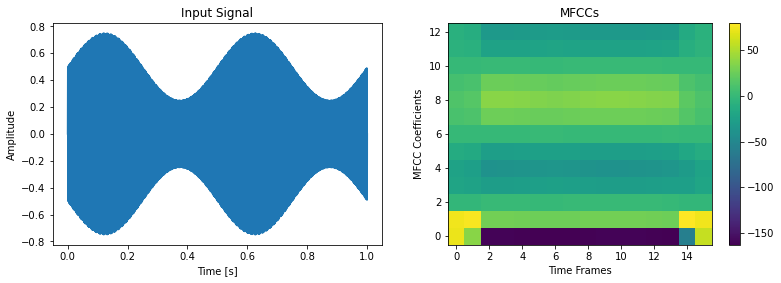

In [2]:
# Sample rate and signal
sample_rate = 8000
duration = 1  # seconds
t = torch.linspace(0, duration, int(sample_rate * duration))
frequency = 440  # A4 note
signal = 0.5 * torch.sin(2 * torch.pi * frequency * t)

# Add a simple amplitude modulation
modulator = 1.0 + 0.5 * torch.sin(2*torch.pi *2*t)
signal = signal*modulator

fig, ax = plt.subplots(1, 2, figsize=(13,4), dpi=72)
ax[0].plot(t.numpy(), signal.numpy())  # plot the signal
ax[0].set(xlabel='Time [s]', ylabel='Amplitude', title='Input Signal')

# Compute MFCCs
n_mfcc = 13
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=sample_rate,
    n_mfcc=n_mfcc,
    melkwargs={
        'n_fft': 2048,
        'n_mels': 40,
        'hop_length': 512,
        'mel_scale': 'htk',
    }
)

mfcc = mfcc_transform(signal.unsqueeze(0))

cax1 = ax[1].imshow(mfcc[0].numpy(), aspect='auto', origin='lower')  # plot MFCCs
ax[1].set(xlabel='Time Frames', ylabel='MFCC Coefficients', title='MFCCs')
fig.colorbar(cax1)
plt.show()

In [ ]:
class WaveNet(nn.Module):
    def __init__(self, quantization_channels=256, residual_channels=32, skip_channels=32, dilation_depth=2, filter_size=2):
        super(WaveNet, self).__init__()
        
        self.quantization_channels = quantization_channels
        self.residual_channels = residual_channels
        self.skip_channels = skip_channels
        self.dilation_depth = dilation_depth
        self.filter_size = filter_size
        
        self.causal_conv = nn.Conv1d(
            in_channels=quantization_channels,
            out_channels=residual_channels,
            kernel_size=filter_size,
            padding=filter_size - 1
        )
        
        self.dilated_convs = nn.ModuleList()
        self.residual_convs = nn.ModuleList()
        self.skip_convs = nn.ModuleList()
        
        for i in range(dilation_depth):
            dilation = 2 ** i
            padding = (filter_size - 1) * dilation

            conv_filter = nn.Conv1d(
                in_channels=residual_channels,
                out_channels=residual_channels,
                kernel_size=filter_size,
                dilation=dilation,
                padding=padding
            )
            conv_gate = nn.Conv1d(
                in_channels=residual_channels,
                out_channels=residual_channels,
                kernel_size=filter_size,
                dilation=dilation,
                padding=padding
            )

            # Convolution Type: Dilated Convolution 
            # Layer Size: 2 
            # Function: allows information to flow through layers without significant loss.
            self.dilated_convs.append(nn.ModuleList([conv_filter, conv_gate]))

            # Type: Residual Connection 
            # Layer Size: 2 
            # Function: adds input of ther layer to its output, helping to mitigate vanishing gradients
            self.residual_convs.append(nn.Conv1d(
                in_channels=residual_channels,
                out_channels=residual_channels,
                kernel_size=1
            ))

            # Type: Skip Connection
            # Layer Size: 1 
            # Function:  allows intermediate layer outputs to bypass several layers and directly contribute to the final outpu
            self.skip_convs.append(nn.Conv1d(
                in_channels=residual_channels,
                out_channels=skip_channels,
                kernel_size=1
            ))
        
        # Rectified linear unit, negative values become 0, positive values stay the same
        self.relu = nn.ReLU()


        # Type: Skip Softmax Output
        # Layer Size: 1 
        # Function: produces a probability distribution over possible next sample values
        self.output_conv1 = nn.Conv1d(
            in_channels=skip_channels,
            out_channels=skip_channels,
            kernel_size=1
        )

        # Type: Skip Softmax Output
        # Layer Size: 1 
        # Function: produces a probability distribution over possible next sample values
        self.output_conv2 = nn.Conv1d(
            in_channels=skip_channels,
            out_channels=quantization_channels,
            kernel_size=1
        )
    
    def forward(self, x):
        # input x shape: (batch_size, seq_len)
        x = F.one_hot(x, num_classes=self.quantization_channels).float()
        # reshape x to (batch_size, channels, seq_len)
        x = x.transpose(1, 2)

        x = self.causal_conv(x)
        x = x[:, :, :- (self.filter_size - 1)]  # Remove padding to make causal
        skip_connections = []
        
        for i in range(self.dilation_depth):
            conv_filter, conv_gate = self.dilated_convs[i]

            filter_out = conv_filter(x)
            gate_out = conv_gate(x)

            pad = (self.filter_size - 1) * (2 ** i)
            filter_out = filter_out[:, :, :-pad]
            gate_out = gate_out[:, :, :-pad]

            tanh_out = torch.tanh(filter_out)
            sigmoid_out = torch.sigmoid(gate_out)
            z = tanh_out * sigmoid_out

            skip = self.skip_convs[i](z)
            skip_connections.append(skip)

            res = self.residual_convs[i](z)
            x = x + res
            
        out = sum(skip_connections)
        out = self.relu(out)
        out = self.output_conv1(out)
        out = self.relu(out)
        out = self.output_conv2(out)

        out = out.mean(dim=2)

        out = F.softmax(out, dim=1)
        return out

In [ ]:
import os

Flist = [os.path.join(PATH_DATA,f) for f in os.listdir(PATH_DATA) if f.lower().endswith('.wav') and f.lower().startswith('cat')]
print(f'#Files= {len(Flist)}')


def preprocess_audio(_path, q_channels=256):
    from torchcodec.decoders import AudioDecoder
    # read the raw audio data
    decoder = AudioDecoder(_path)
    samples = decoder.get_all_samples()

    # for TorchCodec audio shape is (num_channels, num_samples), float32
    audio = samples.data
    
    # The assert is used to ensure mono input for WaveNet
    # I don't know how to check for 16-bit WAV or if that matters?
    assert audio.shape[0] == 1, "Only mono audio (one channel) is supported"
    
    # remove the channel dimension
    audio = audio.squeeze(0)

    # audio could be on gpu, need to convert it to cpu for numpy
    audio = audio.cpu().numpy()

    audio /= np.max(np.abs(audio))  # normalize to [-1, 1] range

    # µ-law encoding
    mu = q_channels - 1
    audio_mu = np.sign(audio) * np.log1p(mu*np.abs(audio)) / np.log1p(mu)
    quantized_audio = ((audio_mu + 1) / 2*mu).astype(np.int64)
    
    # convert to tensor with the shape (1, seq_length)
    audio_tensor = torch.tensor(quantized_audio, dtype=torch.long).unsqueeze(0)
    return audio_tensor

# sanity
x = preprocess_audio(PATH_DATA+'cat_1.wav')
print(x.shape)

#Files= 164
torch.Size([1, 179200])


In [6]:
def pad_seq(_x, target_length):
    T = _x.size(1)
    if T < target_length:
        padding = target_length - T  # pad with zeros at the end
        x = torch.cat([_x, torch.zeros(1, padding, dtype=torch.long)], dim=1)
    return x

def truncate_seq(_x, target_length):
    if _x.size(1) > target_length:
        x = _x[:, :target_length]
    return x

def split_into_chunks(_x, chunk_length):
    total_length = _x.size(1)
    num_chunks = total_length // chunk_length
    chunks = [_x[:, i * chunk_length: (i + 1) * chunk_length] for i in range(num_chunks)]
    
    # handle remainder
    remainder = total_length % chunk_length
    if remainder:
        last_chunk = _x[:, -chunk_length:]  # take the last chunk with padding if needed
        chunks.append(last_chunk)
    
    return chunks

# sanity
chunks = split_into_chunks(x, chunk_length=16000)
print(f"Total chunks: {len(chunks)}")

Total chunks: 12


In [12]:
class AudioDataset(Dataset):
    def __init__(self, audio_files, target_length=16000, q_channels=256):
        self.audio_files = audio_files
        self.target_length = target_length
        self.q_channels = q_channels
    
    def __len__(self):
        return len(self.audio_files)
    
    def __getitem__(self, idx):
        audio_tensor = preprocess_audio(self.audio_files[idx], self.q_channels)
        
        # pad or truncate
        if audio_tensor.size(1) < self.target_length:
            audio_tensor = pad_seq(audio_tensor, target_length=self.target_length)
        elif audio_tensor.size(1) > self.target_length:
            audio_tensor = truncate_seq(audio_tensor, target_length=self.target_length)
        
        return audio_tensor.squeeze(0)  # remove batch dimension for DataLoader compatibility

dataset = AudioDataset(Flist)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)